In [261]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import brentq

blog_visuals = Path("visuals")
blog_visuals.mkdir(parents=True, exist_ok=True)

FIG_SIZE = (8.8, 5.6)
EXPORT_DPI = 220
THUMBNAIL_SIZE = (11, 6.3)
THUMBNAIL_DPI = 100

plt.rcParams.update({"axes.titlesize": 14, "axes.labelsize": 13,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 11})

In [ ]:
csv_path = Path("t20_table.csv")
df = pd.read_csv(csv_path)
overs_grid = df.iloc[:, 0].to_numpy(dtype=float)
wickets_grid = np.arange(11, dtype=float)

z_pct = np.column_stack([df[col].astype(str).str.split("/", expand=True)[0]
                         .astype(float).to_numpy() for col in df.columns[1:]])
z_pct = np.column_stack((z_pct, np.full(len(df), 100.0)))
z_grid = z_pct / 100.0

interpolator = RegularGridInterpolator((overs_grid, wickets_grid), z_grid, method="linear", bounds_error=True)
t_dense = np.linspace(0, 20, 161)
w_dense = np.linspace(0, 10, 101)
TT, WW = np.meshgrid(t_dense, w_dense, indexing="xy")
ZZ = interpolator(np.column_stack([TT.ravel(), WW.ravel()])).reshape(WW.shape)

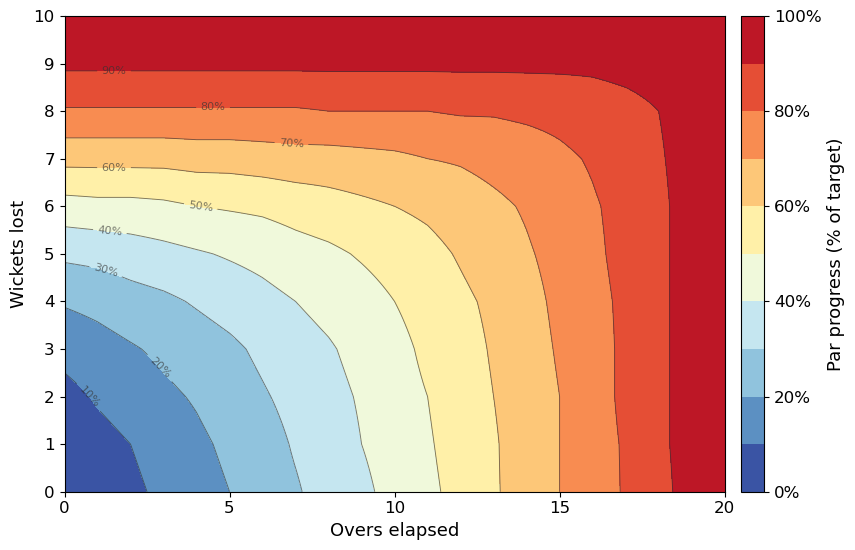

In [263]:
# Shared styling for all six plots
levels = np.linspace(0, 1, 11)
cmap = "RdYlBu_r"
contour_color = "#333333"
actual_point_color = "#111111"
actual_point_edge = "white"
actual_contour_color = "#111111"
trifecta_purple = "#8a2be2"

fig_base, ax_base = plt.subplots(figsize=FIG_SIZE)
cf_base = ax_base.contourf(TT, WW, ZZ, levels=levels, cmap=cmap, vmin=0, vmax=1)
cs_base = ax_base.contour(TT, WW, ZZ, levels=levels, colors=contour_color, linewidths=0.65, alpha=0.65)
ax_base.clabel(cs_base, fmt=lambda v: f"{v * 100:.0f}%", fontsize=8)

ax_base.set_xlabel("Overs elapsed")
ax_base.set_ylabel("Wickets lost")
ax_base.set_xlim(0, 20)
ax_base.set_ylim(0, 10)
ax_base.set_xticks(np.arange(0, 21, 5))
ax_base.yaxis.set_major_locator(MaxNLocator(integer=True))

cbar_base = fig_base.colorbar(cf_base, ax=ax_base, pad=0.02)
cbar_base.set_label("Par progress (% of target)")
cbar_base.set_ticks(np.linspace(0, 1, 6))
cbar_base.set_ticklabels([f"{x:.0f}%" for x in np.linspace(0, 100, 6)])

fig_base.tight_layout()
plt.show()

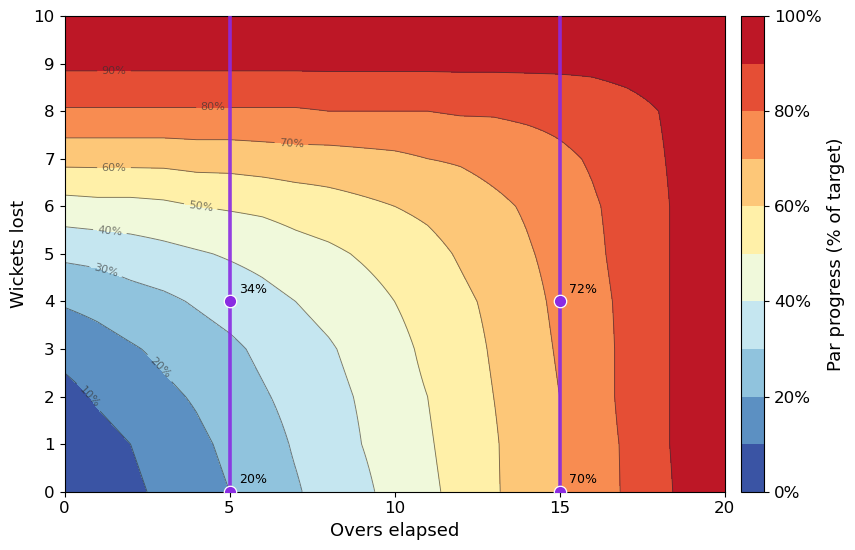

In [264]:
fig_verts, ax_verts = plt.subplots(figsize=FIG_SIZE)
cf_verts = ax_verts.contourf(TT, WW, ZZ, levels=levels, cmap=cmap, vmin=0, vmax=1)
cs_verts = ax_verts.contour(TT, WW, ZZ, levels=levels, colors=contour_color, linewidths=0.65, alpha=0.65)
ax_verts.clabel(cs_verts, fmt=lambda v: f"{v * 100:.0f}%", fontsize=8)

verts_color = trifecta_purple
for x in [5, 15]:
    ax_verts.axvline(x, color=verts_color, linewidth=2.6, alpha=0.9, zorder=4)

points = [(5, 0), (5, 4), (15, 0), (15, 4)]
ax_verts.scatter([x for x, _ in points], [y for _, y in points], s=80, c=verts_color, edgecolors="white", linewidths=0.9, zorder=5)
for x, y in points:
    z = float(interpolator([[x, y]])[0])
    ax_verts.text(x + 0.28, y + 0.18, f"{100 * z:.0f}%", color="black", fontsize=9, zorder=6)

ax_verts.set_xlabel("Overs elapsed")
ax_verts.set_ylabel("Wickets lost")
ax_verts.set_xlim(0, 20)
ax_verts.set_ylim(0, 10)
ax_verts.set_xticks(np.arange(0, 21, 5))
ax_verts.yaxis.set_major_locator(MaxNLocator(integer=True))

cbar_verts = fig_verts.colorbar(cf_verts, ax=ax_verts, pad=0.02)
cbar_verts.set_label("Par progress (% of target)")
cbar_verts.set_ticks(np.linspace(0, 1, 6))
cbar_verts.set_ticklabels([f"{x:.0f}%" for x in np.linspace(0, 100, 6)])

fig_verts.tight_layout()
plt.show()

In [275]:
# Easy-to-change example state
target, score, overs_elapsed, wickets_lost = 177, 147, 15, 4
z_actual = score / target
z_par = float(interpolator([[overs_elapsed, wickets_lost]])[0])
par_score = target * z_par
runs_ahead = score - par_score

g_lo = float(interpolator([[overs_elapsed, 0.0]])[0] - z_actual)
g_hi = float(interpolator([[overs_elapsed, 10.0]])[0] - z_actual)
w_par = float(brentq(lambda w: float(interpolator([[overs_elapsed, w]])[0] - z_actual), 0.0, 10.0))

h_lo = float(interpolator([[0.0, wickets_lost]])[0] - z_actual)
h_hi = float(interpolator([[20.0, wickets_lost]])[0] - z_actual)
t_par = float(brentq(lambda t: float(interpolator([[t, wickets_lost]])[0] - z_actual), 0.0, 20.0))

wickets_delta = wickets_lost - w_par
overs_delta = overs_elapsed - t_par

runs_side = "ahead" if runs_ahead > 0 else ("behind" if runs_ahead < 0 else "level")
wickets_side = "ahead" if wickets_delta < 0 else ("behind" if wickets_delta > 0 else "level")
overs_side = "ahead" if overs_delta < 0 else ("behind" if overs_delta > 0 else "level")
print(f"Runs: {abs(runs_ahead):.2f} {runs_side}")
print(f"Wickets: {abs(wickets_delta):.2f} {wickets_side}")
print(f"Overs: {abs(overs_delta):.2f} {overs_side}")

Runs: 19.56 ahead
Wickets: 4.01 ahead
Overs: 2.18 ahead


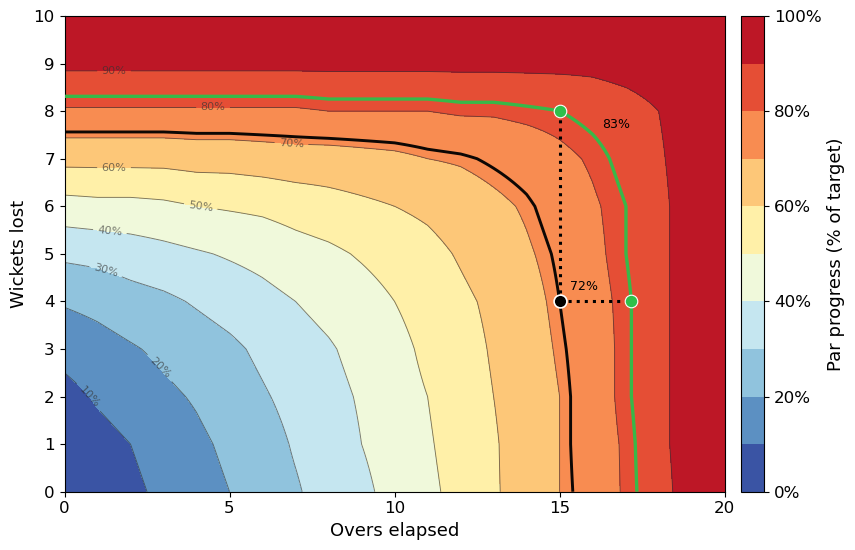

In [276]:
fig_runs, ax_runs = plt.subplots(figsize=FIG_SIZE)
cf_runs = ax_runs.contourf(TT, WW, ZZ, levels=levels, cmap=cmap, vmin=0, vmax=1)
cs_runs = ax_runs.contour(TT, WW, ZZ, levels=levels, colors=contour_color, linewidths=0.65, alpha=0.65)
ax_runs.clabel(cs_runs, fmt=lambda v: f"{v * 100:.0f}%", fontsize=8)

actual_green = "#2fbf4a"
ax_runs.contour(TT, WW, ZZ, levels=[z_par], colors="black", linewidths=2.1, alpha=0.95, zorder=4)
ax_runs.contour(TT, WW, ZZ, levels=[z_actual], colors=actual_green, linewidths=2.4, alpha=0.95, zorder=5)
ax_runs.scatter([overs_elapsed], [wickets_lost], s=85, c="black", edgecolor="white", linewidth=1.2, zorder=6)
ax_runs.scatter([overs_elapsed], [w_par], s=82, c=actual_green, edgecolor="white", linewidth=0.8, zorder=7)
ax_runs.scatter([t_par], [wickets_lost], s=82, c=actual_green, edgecolor="white", linewidth=0.8, zorder=7)
ax_runs.plot([overs_elapsed, overs_elapsed], [wickets_lost, w_par], c="black", linewidth=2.2, linestyle=":", zorder=6)
ax_runs.plot([overs_elapsed, t_par], [wickets_lost, wickets_lost], c="black", linewidth=2.2, linestyle=":", zorder=6)
ax_runs.text(overs_elapsed + 0.3, wickets_lost + 0.25, f"{100 * z_par:.0f}%", color="black", fontsize=9, zorder=7)
ax_runs.text(16.3, 7.65, f"{100 * z_actual:.0f}%", color="black", fontsize=9, zorder=7)

ax_runs.set_xlabel("Overs elapsed")
ax_runs.set_ylabel("Wickets lost")
ax_runs.set_xlim(0, 20)
ax_runs.set_ylim(0, 10)
ax_runs.set_xticks(np.arange(0, 21, 5))
ax_runs.yaxis.set_major_locator(MaxNLocator(integer=True))

cbar_runs = fig_runs.colorbar(cf_runs, ax=ax_runs, pad=0.02)
cbar_runs.set_label("Par progress (% of target)")
cbar_runs.set_ticks(np.linspace(0, 1, 6))
cbar_runs.set_ticklabels([f"{x:.0f}%" for x in np.linspace(0, 100, 6)])

fig_runs.tight_layout()
plt.show()

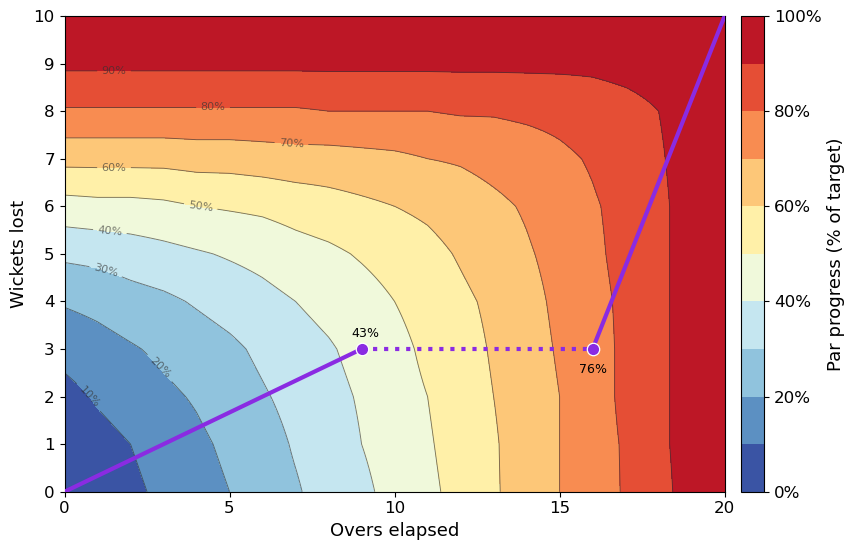

In [267]:
fig_rain, ax_rain = plt.subplots(figsize=FIG_SIZE)
cf_rain = ax_rain.contourf(TT, WW, ZZ, levels=levels, cmap=cmap, vmin=0, vmax=1)
cs_rain = ax_rain.contour(TT, WW, ZZ, levels=levels, colors=contour_color, linewidths=0.65, alpha=0.65)
ax_rain.clabel(cs_rain, fmt=lambda v: f"{v * 100:.0f}%", fontsize=8)

rain_color = trifecta_purple
ax_rain.plot([0, 9], [0, 3], color=rain_color, linewidth=3.0, zorder=7)
ax_rain.plot([9, 16], [3, 3], color=rain_color, linewidth=3.0, linestyle=":", zorder=7)
ax_rain.plot([16, 20], [3, 10], color=rain_color, linewidth=3.0, zorder=7)

rain_points = [(9, 3), (16, 3)]
ax_rain.scatter([x for x, _ in rain_points], [y for _, y in rain_points], s=80, c=trifecta_purple, edgecolors="white", linewidths=0.9, zorder=8)

z_pause_start = float(interpolator([[9, 3]])[0])
z_pause_end = float(interpolator([[16, 3]])[0])
ax_rain.text(8.7, 3.25, f"{100 * z_pause_start:.0f}%", color="black", fontsize=9, zorder=9)
ax_rain.text(15.6, 2.5, f"{100 * z_pause_end:.0f}%", color="black", fontsize=9, zorder=9)

ax_rain.set_xlabel("Overs elapsed")
ax_rain.set_ylabel("Wickets lost")
ax_rain.set_xlim(0, 20)
ax_rain.set_ylim(0, 10)
ax_rain.set_xticks(np.arange(0, 21, 5))
ax_rain.yaxis.set_major_locator(MaxNLocator(integer=True))

cbar_rain = fig_rain.colorbar(cf_rain, ax=ax_rain, pad=0.02)
cbar_rain.set_label("Par progress (% of target)")
cbar_rain.set_ticks(np.linspace(0, 1, 6))
cbar_rain.set_ticklabels([f"{x:.0f}%" for x in np.linspace(0, 100, 6)])

fig_rain.tight_layout()
plt.show()

In [272]:
figures_to_export = {
    "dls-base.png": fig_base,
    "dls-verts.png": fig_verts,
    "dls-rain.png": fig_rain,
    "dls-runs.png": fig_runs,
}

for name, fig in figures_to_export.items():
    fig.savefig(blog_visuals / name, dpi=EXPORT_DPI, bbox_inches="tight")

thumb_path = blog_visuals / "thumbnail-dls-runs.png"
original_size = fig_runs.get_size_inches().copy()
fig_runs.set_size_inches(*THUMBNAIL_SIZE)
fig_runs.savefig(thumb_path, dpi=THUMBNAIL_DPI)
fig_runs.set_size_inches(*original_size)